In [2]:
#importing Libraries 
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


c:\Users\vshru\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()


Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\vshru\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Feb 26 15:22:25 2026).


In [ ]:
#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df.info()

In [26]:
#Count - counts non-na values from each group (value/column required)
#size - counts all rows in a group (value/column not required)
df_job_country_salary =df.pivot_table(index='job_country',values = 'salary_year_avg',columns = 'job_title_short',aggfunc='median')

In [14]:
df.groupby('job_title_short')['salary_year_avg'].median()

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Data Engineer                125000.0
Data Scientist               127500.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Software Engineer             99150.0
Name: salary_year_avg, dtype: float64

In [33]:
#value_counts - tells how many times each unique value appears in a column
top_countries = df['job_country'].value_counts().head(6).index

In [34]:
top_countries

Index(['United States', 'India', 'United Kingdom', 'France', 'Germany',
       'Spain'],
      dtype='str', name='job_country')

In [35]:
df_job_country_salary = df_job_country_salary.loc[top_countries]

In [36]:
df_job_country_salary

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
United States,90000.0,116100.0,90000.0,125000.0,130000.0,150000.0,110000.0,150000.0,155000.0,130000.0
India,64800.0,NaN,100500.0,147500.0,114008.0,79200.0,111175.0,147500.0,149653.0,79200.0
United Kingdom,56700.0,NaN,87750.0,110000.0,105300.0,149653.0,111175.0,147500.0,157500.0,89100.0
France,89100.0,105968.0,69175.0,98301.5,88128.0,80850.0,111175.0,147500.0,157500.0,142500.0
Germany,89100.0,89100.0,103750.0,147500.0,131560.0,89100.0,111175.0,147500.0,157500.0,84975.0
Spain,86400.0,89100.0,91977.0,133000.0,88128.0,101029.0,111175.0,147500.0,157500.0,77050.0


In [39]:
job_titles = ['Data Engineer','Data Engineer','Data Scientist']

In [ ]:
#column filtering
df_job_country_salary = df_job_country_salary[job_titles]


In [41]:
df_job_country_salary

job_title_short,Data Engineer,Data Engineer,Data Scientist
job_country,,,
United States,125000.0,125000.0,130000.0
India,147500.0,147500.0,114008.0
United Kingdom,110000.0,110000.0,105300.0
France,98301.5,98301.5,88128.0
Germany,147500.0,147500.0,131560.0
Spain,133000.0,133000.0,88128.0


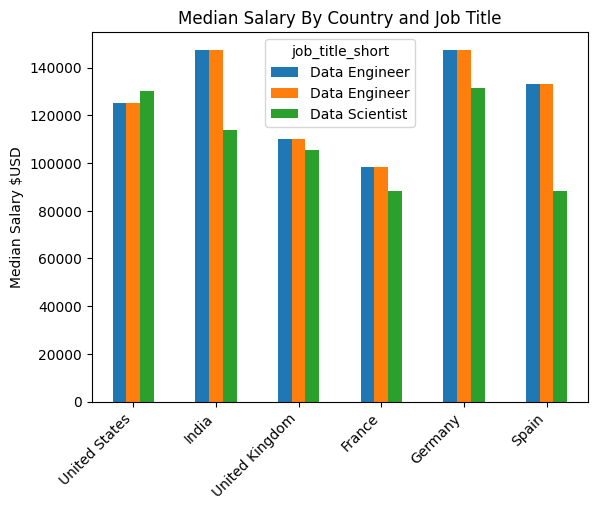

In [43]:
df_job_country_salary.plot(kind='bar')
plt.xlabel("")
plt.ylabel("Median Salary $USD")
plt.title("Median Salary By Country and Job Title")
plt.xticks(rotation = 45,ha='right')
plt.show()